In [47]:
import pandas as pd
import geopandas

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

from pathlib import Path
import glob

In [48]:
PATH = Path('../KNPAnthrax/bin/Debug/net6.0/')

In [49]:
impalas = glob.glob((PATH / 'Impala_path_*.geojson').as_posix())
impala_gdfs = []

for f in impalas:
    gdf = geopandas.read_file(f)
    impala_gdfs.append(gdf)
    
impala_gdf = pd.concat(impala_gdfs)

<AxesSubplot: >

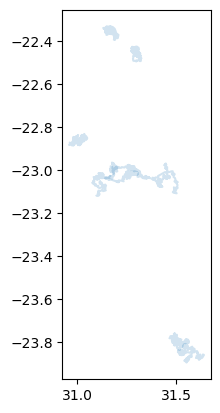

In [50]:
impala_gdf.plot(alpha=0.2)

In [51]:
kudus = glob.glob((PATH / 'Kudu_path_*.geojson').as_posix())
kudu_gdfs = []

for f in kudus:
    gdf = geopandas.read_file(f)
    kudu_gdfs.append(gdf)
    
kudu_gdf = pd.concat(kudu_gdfs)

<AxesSubplot: >

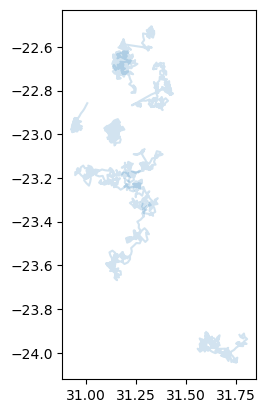

In [52]:
kudu_gdf.plot(alpha=0.2)

In [53]:
import keplergl

In [54]:
with open(PATH / 'LandscapeLayer_types.geojson', 'r') as f:
    LandscapeLayer_types = f.read()
    
# Loads trips with movement of agents
with open(PATH / 'Resources/water/knp_water_north_merged.geojson', 'r') as f:
    knp_water_north_merged = f.read()
    

In [55]:
# load the config
%run map_config.py

In [56]:
# show the map, to add data run the next cell 
map_1 = keplergl.KeplerGl(height=700, config=config)
map_1

User Guide: https://docs.kepler.gl/docs/keplergl-jupyter


KeplerGl(config={'version': 'v1', 'config': {'visState': {'filters': [], 'layers': [{'id': 'vdi4ky', 'type': '…

In [57]:
map_1.add_data(LandscapeLayer_types, "LandscapeLayer")
map_1.add_data(knp_water_north_merged, "Watersources")
map_1.add_data(impala_gdf.to_json(), "Impalas")
map_1.add_data(kudu_gdf.to_json(), "Kudu")

In [58]:
# IMPORTANT! Changes made inside the map widget will be lost, after restarting the Notebook.
# If you editied anythin run this cell to persist the configuration.
with open('map_config.py', 'w') as f:
    f.write('config = {}'.format(map_1.config))